# Notebook to simulate aberrations


In [1]:
import subprocess
import time
import os
import tango
import json
import numpy as np
import matplotlib.pyplot as plt

In [2]:
""" Run servers in DB mode
Steps to run the servers - see scripts/README_db_mode.md

Terminal 1:
TANGO_HOST=localhost:11000 uv run python -m tango.databaseds.database 2

Terminal 2:
export TANGO_HOST=localhost:11000 
uv run scripts/2_register_devices.py 

Terminal 3:
export TANGO_HOST=localhost:11000 
uv run python -m asyncroscopy.hardware.SCAN scan_instance

Terminal 4:
export TANGO_HOST=localhost:11000 
uv run python -m asyncroscopy.hardware.CORRECTOR corrector_instance

Terminal 5:
export TANGO_HOST=localhost:11000 
uv run python -m asyncroscopy.ThermoDigitalTwin microscope_twin_instance
"""


' Run servers in DB mode\nSteps to run the servers - see scripts/README_db_mode.md\n\nTerminal 1:\nTANGO_HOST=localhost:11000 uv run python -m tango.databaseds.database 2\n\nTerminal 2:\nexport TANGO_HOST=localhost:11000 \nuv run scripts/2_register_devices.py \n\nTerminal 3:\nexport TANGO_HOST=localhost:11000 \nuv run python -m asyncroscopy.hardware.SCAN scan_instance\n\nTerminal 4:\nexport TANGO_HOST=localhost:11000 \nuv run python -m asyncroscopy.hardware.CORRECTOR corrector_instance\n\nTerminal 5:\nexport TANGO_HOST=localhost:11000 \nuv run python -m asyncroscopy.ThermoDigitalTwin microscope_twin_instance\n'

In [3]:
# Tango DB running on this
os.environ["TANGO_HOST"] = "localhost:11000"
# os.environ["TANGO_HOST"] = "10.46.217.241:9094"


# list devices on DB
db = tango.Database()
devices = db.get_device_name("*", "*")
print("Devices registered in Tango DB:\n")
for d in devices:
    print(d)

Devices registered in Tango DB:

dserver/CAMERA/camera_instance
dserver/CORRECTOR/corrector_instance
dserver/DataBaseds/2
dserver/EDS/eds_instance
dserver/SCAN/scan_instance
dserver/STAGE/stage_instance
dserver/TangoAccessControl/1
dserver/TangoTest/test
dserver/ThermoDigitalTwin/microscope_twin_instance
dserver/ThermoMicroscope/microscope_instance
sys/access_control/1
sys/database/2
sys/tg_test/1
test/camera/1
test/corrector/1
test/eds/1
test/microscope/1
test/microscope_twin/1
test/scan/1
test/stage/1


In [4]:
# set timeouts
scan = tango.DeviceProxy("test/scan/1")
mic_proxy = tango.DeviceProxy("test/microscope_twin/1")
corrector_proxy = tango.DeviceProxy("test/corrector/1")

scan.set_timeout_millis(120_000)
mic_proxy.set_timeout_millis(120_000)
corrector_proxy.set_timeout_millis(120_000)

In [5]:
print('\n--- Microscope commands ---')
for cmd in mic_proxy.get_command_list():
    print(f'  {cmd}')

print('\n--- Microscope commands ---')
for cmd in corrector_proxy.get_command_list():
    print(f'  {cmd}')

print('\n--- Microscope commands ---')
for cmd in scan.get_command_list():
    print(f'  {cmd}')


--- Microscope commands ---
  Connect
  Disconnect
  Init
  State
  Status
  auto_focus
  blank_beam
  get_camera_image
  get_fov
  get_image_data_cached
  get_images
  get_scanned_image
  get_scanned_image_with_aberrations
  get_screen_current
  get_spectrum
  get_stage
  move_stage
  place_beam
  set_fov
  set_image_shift
  set_screen_current
  unblank_beam

--- Microscope commands ---
  Init
  State
  Status
  acquire_tableau
  correct_aberration
  get_aberrations_coeff_sim
  get_info
  measure_c1a1
  reconnect
  set_aberrations_coeff_sim

--- Microscope commands ---
  Activate
  Init
  State
  Status


In [6]:
import sys
import ast
import matplotlib.pyplot as plt

import pyTEMlib
from pyTEMlib import probe_tools as pt

In [7]:
# Generate aberrations and upload on the device
aberrations = pt.get_target_aberrations("Spectra300", 60000)
pt.print_aberrations(aberrations)

In [8]:
aberrations_in = json.dumps(aberrations)
corrector_proxy.set_aberrations_coeff_sim(aberrations_in)

In [9]:
aberrations_read = corrector_proxy.get_aberrations_coeff_sim()
json.loads(aberrations_read)

{'C10': 0,
 'C12a': 0,
 'C12b': 0.38448128113770325,
 'C21a': -68.45251255685642,
 'C21b': 64.85359774641199,
 'C23a': 11.667578600494137,
 'C23b': -29.775627778458194,
 'C30': 123,
 'C32a': 95.3047364258614,
 'C32b': -189.72105710231244,
 'C34a': -47.45099594807912,
 'C34b': -94.67424667529909,
 'C41a': -905.31842572806,
 'C41b': 981.316128853203,
 'C43a': 4021.8433526960034,
 'C43b': 131.72716642732158,
 'C45a': -4702.390968272048,
 'C45b': -208.25028574642903,
 'C50': 552000.0,
 'C52a': -0.0,
 'C52b': 0.0,
 'C54a': -0.0,
 'C54b': -0.0,
 'C56a': -36663.643489934424,
 'C56b': 21356.079837905396,
 'acceleration_voltage': 200000,
 'FOV': 34.241659495148205,
 'Cc': 1000000.0,
 'convergence_angle': 30,
 'wavelength': 0.0025079340450548005}

In [10]:
scan.dwell_time = 10e-6
scan.imsize = 905 ######

Metadata: {'detector': 'haadf', 'shape': [905, 905], 'dtype': 'float32', 'dwell_time': 1e-05, 'timestamp': 1777838390.187684}


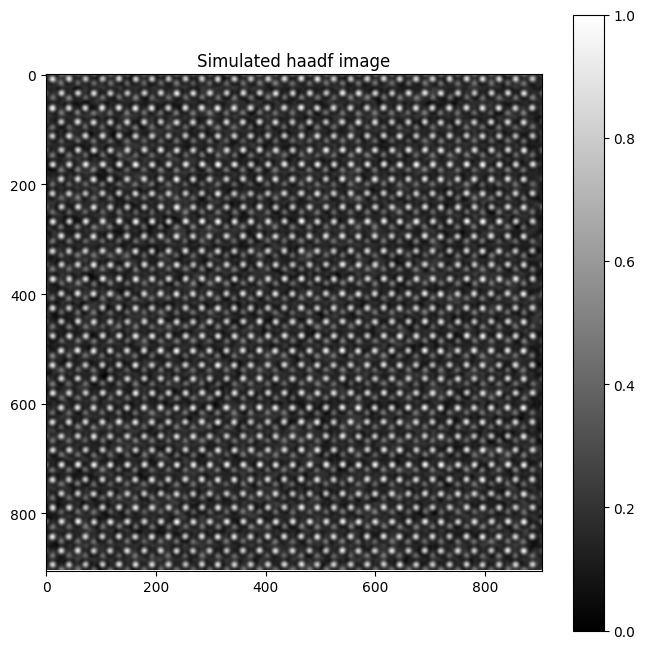

In [14]:
# Upload abberations on the twin
json_meta, raw_bytes = mic_proxy.get_scanned_image_with_aberrations()
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()


In [15]:
# change dwell time -> less brighter atomic columns
scan.dwell_time = 0.001e-6


Metadata: {'detector': 'haadf', 'shape': [905, 905], 'dtype': 'float32', 'dwell_time': 1e-09, 'timestamp': 1777838397.137355}


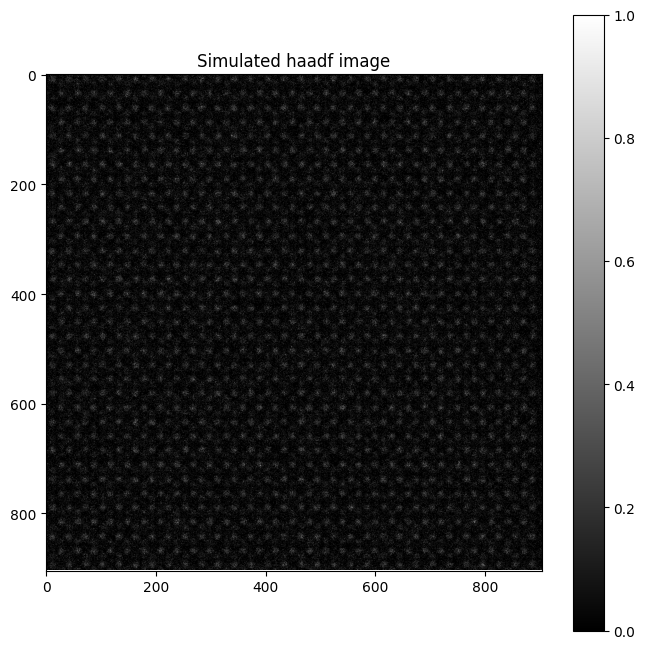

In [16]:
# Upload abberations on the twin
json_meta, raw_bytes = mic_proxy.get_scanned_image_with_aberrations()
meta = json.loads(json_meta)
print(f"Metadata: {meta}")

image = np.frombuffer(raw_bytes, dtype=meta["dtype"]).reshape(meta["shape"])

plt.figure(figsize=(8, 8))
plt.imshow(image.T, cmap='gray')
plt.title(f"Simulated {meta['detector']} image")
plt.colorbar()
plt.show()
